In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import gpxpy
from fitparse import FitFile
import zipfile
import gzip

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [47]:


folder = r"C:\Users\elois\OneDrive\Desktop\vitality-behaviour-analysis\data\activities"

activities = []

In [48]:
for file in os.listdir(folder):

    if file.endswith(".gpx"):
        
        path = os.path.join(folder, file)

        with open(path, "r", encoding="utf-8") as gpx_file:
            gpx = gpxpy.parse(gpx_file)

        for track in gpx.tracks:
            for segment in track.segments:

                start_time = segment.points[0].time
                end_time = segment.points[-1].time

                duration = (end_time - start_time).total_seconds() / 60
                distance = segment.length_2d() / 1000

                activities.append({
                    "date": start_time,
                    "duration_min": duration,
                    "distance_km": distance
                })

In [49]:
df = pd.DataFrame(activities)

df.head()

len(df)


152

In [50]:

df['date'] = pd.to_datetime(df['date'])

df['weekday'] = df['date'].dt.day_name()

df['week'] = df['date'].dt.to_period('W')

C:\Users\elois\AppData\Local\Temp\ipykernel_24312\917562404.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['date'].dt.to_period('W')


In [51]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.day_name()
df['week'] = df['date'].dt.to_period('W')

df.head()

df['weekday_num'] = df['date'].dt.weekday #analyse Monday vs Friday behaviour.

C:\Users\elois\AppData\Local\Temp\ipykernel_24312\886246768.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['date'].dt.to_period('W')


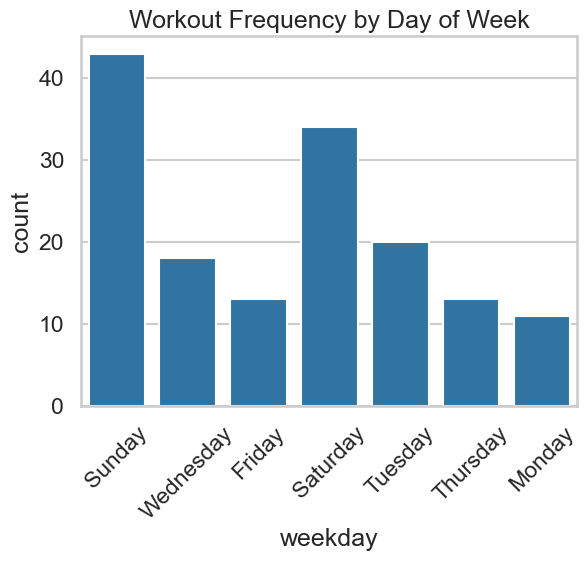

In [52]:
#first insight visual, since Vitality weeks end on Fridays
sns.countplot(data=df, x='weekday')

plt.title("Workout Frequency by Day of Week")
plt.xticks(rotation=45)
plt.show()

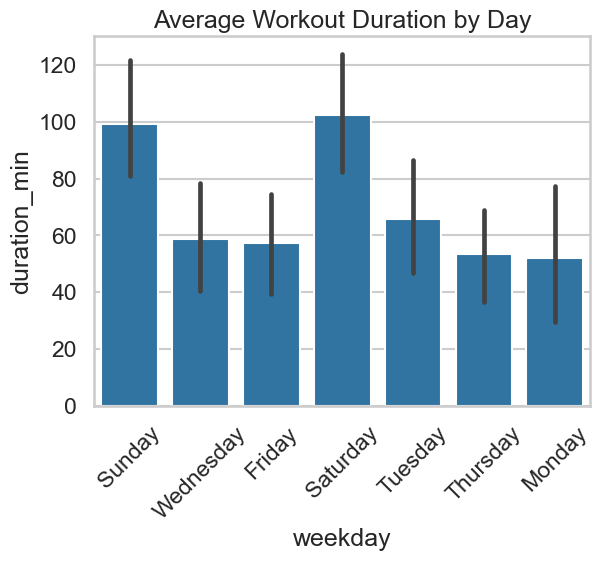

In [53]:
#Total workout time by day
df.groupby('weekday')['duration_min'].mean().sort_values()

#visually
sns.barplot(data=df, x='weekday', y='duration_min')

plt.title("Average Workout Duration by Day")
plt.xticks(rotation=45)
plt.show()

Weekly Effort

In [54]:
weekly = df.groupby('week').agg({
    'duration_min':'sum',
    'distance_km':'sum',
    'date':'count'
})

weekly = weekly.rename(columns={'date':'num_workouts'})
weekly.head()

,duration_min,distance_km,num_workouts
week,,,
2014-12-22/2014-12-28,235.750000,39.980775,5
2014-12-29/2015-01-04,240.616667,53.771376,3
2015-01-05/2015-01-11,171.166667,30.511913,2
2015-01-26/2015-02-01,139.416667,25.088437,2
2015-02-02/2015-02-08,83.050000,28.884659,2


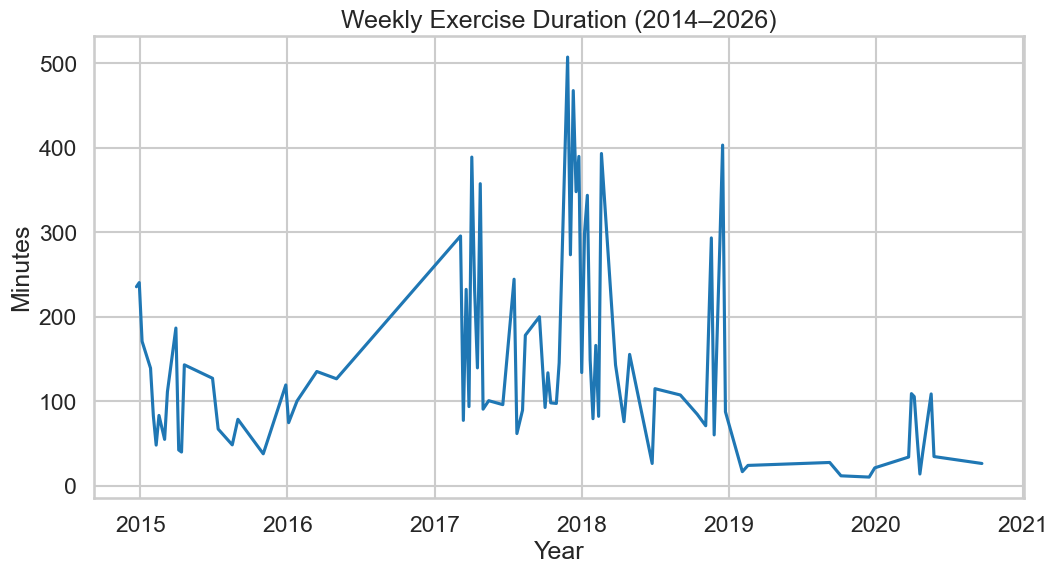

In [55]:
weekly = df.groupby('week').agg({
    'duration_min':'sum',
    'distance_km':'sum',
    'date':'count'
}).rename(columns={'date':'num_workouts'})

weekly.index = weekly.index.to_timestamp()
weekly = weekly.sort_index()

plt.figure(figsize=(12,6))

plt.plot(weekly.index, weekly['duration_min'])

plt.title("Weekly Exercise Duration (2014–2026)")
plt.ylabel("Minutes")
plt.xlabel("Year")

plt.show()

In [56]:
sns.set_style("whitegrid")
sns.set_context("talk")

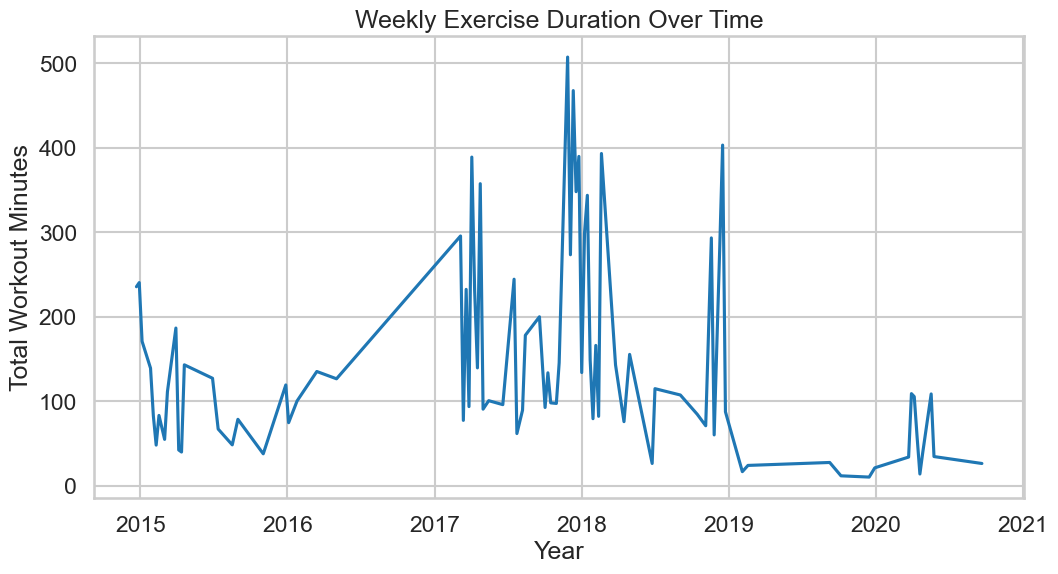

In [57]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=weekly,
    x=weekly.index,
    y='duration_min'
)

plt.title("Weekly Exercise Duration Over Time")
plt.xlabel("Year")
plt.ylabel("Total Workout Minutes")

plt.show()

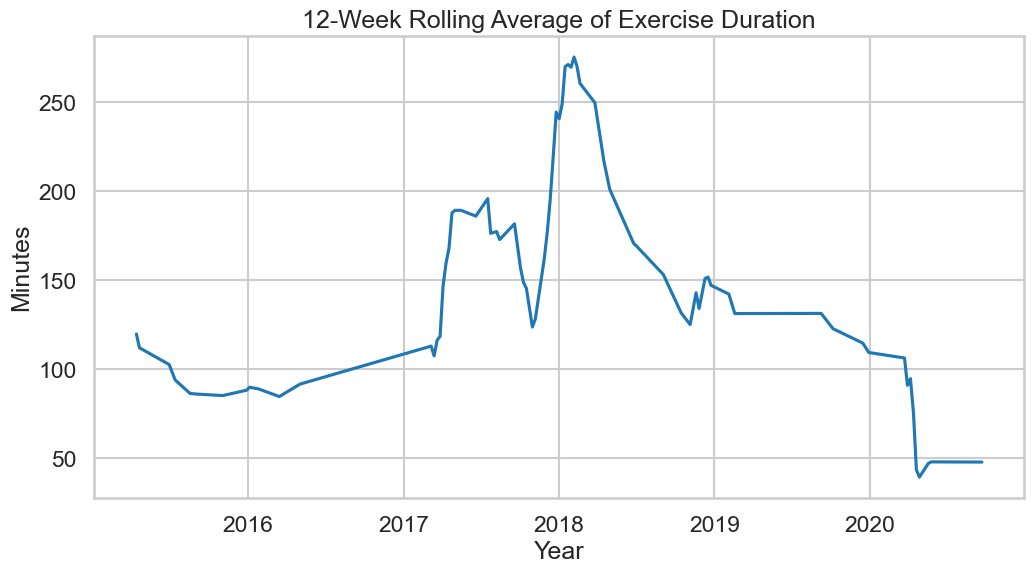

In [58]:
weekly['rolling_12week'] = weekly['duration_min'].rolling(12).mean()

plt.figure(figsize=(12,6))

plt.plot(weekly.index, weekly['rolling_12week'])

plt.title("12-Week Rolling Average of Exercise Duration")
plt.ylabel("Minutes")
plt.xlabel("Year")

plt.show()

In [59]:
df['date'].min(), df['date'].max()

(Timestamp('2014-12-25 03:30:06+0000', tz='SimpleTZ('Z')'),
 Timestamp('2020-09-23 04:52:02+0000', tz='SimpleTZ('Z')'))

Distance vs Duration

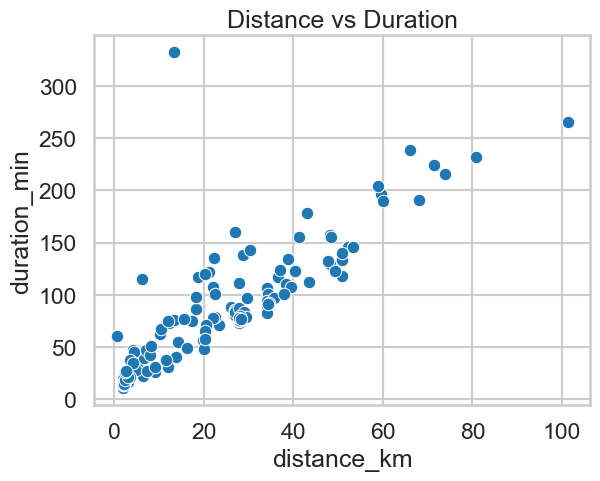

In [60]:
sns.scatterplot(data=df, x='distance_km', y='duration_min')

plt.title("Distance vs Duration")
plt.show()

Can we predict by Wednesday whether a person will hit their weekly activity goal by Friday?

In [25]:
import io

In [26]:

for file in os.listdir(folder):
    path = os.path.join(folder, file)
    
    # ----- 1. Plain .fit file -----
    if file.lower().endswith('.fit'):
        try:
            fitfile = FitFile(path)
            data = _extract_fit_data(fitfile)          # helper function below
            if data:
                activities.append(data)
        except Exception as e:
            print(f"Error reading {file}: {e}")
    
    # ----- 2. Zipped .fit ( .zip or .fit.zip ) -----
    elif file.lower().endswith(('.zip', '.fit.zip')):
        try:
            with zipfile.ZipFile(path) as z:
                for name in z.namelist():
                    if name.lower().endswith('.fit'):
                        with z.open(name) as f:
                            fit_data = f.read()
                            fitfile = FitFile(io.BytesIO(fit_data))
                            data = _extract_fit_data(fitfile)
                            if data:
                                activities.append(data)
                        break  # one activity per zip is normal
        except Exception as e:
            print(f"Error reading zip {file}: {e}")
    
    # ----- 3. Gzipped .fit (optional safety net) -----
    elif file.lower().endswith(('.gz', '.fit.gz')):
        try:
            with gzip.open(path, 'rb') as f:
                fit_data = f.read()
                fitfile = FitFile(io.BytesIO(fit_data))
                data = _extract_fit_data(fitfile)
                if data:
                    activities.append(data)
        except Exception as e:
            print(f"Error reading gz {file}: {e}")

# Helper function (keeps the code clean)
def _extract_fit_data(fitfile):
    timestamps = []
    heart_rates = []
    distances = []

    for record in fitfile.get_messages("record"):
        time = record.get_value("timestamp")
        hr = record.get_value("heart_rate")
        dist = record.get_value("distance")
        
        if time: timestamps.append(time)
        if hr:   heart_rates.append(hr)
        if dist: distances.append(dist)

    if not timestamps:
        return None

    start_time = min(timestamps)
    end_time = max(timestamps)
    duration_min = (end_time - start_time).total_seconds() / 60
    avg_hr = np.mean(heart_rates) if heart_rates else None
    total_distance_km = distances[-1] / 1000 if distances else None

    return {
        "date": start_time,
        "duration_min": duration_min,
        "distance_km": total_distance_km,
        "avg_hr": avg_hr,
        "source": "fit"   # useful when you merge with your existing gpx DataFrame
    }

In [28]:
df_fit = pd.DataFrame(activities)

# Fix the timezone mess
df_fit['date'] = pd.to_datetime(df_fit['date'], utc=True, errors='coerce').dt.tz_localize(None)

# Drop any bad rows (if parsing failed)
df_fit = df_fit.dropna(subset=['date']).copy()

df_fit['weekday'] = df_fit['date'].dt.day_name()
df_fit['week'] = df_fit['date'].dt.to_period('W')
df_fit['weekday_num'] = df_fit['date'].dt.weekday

print(f"Processed {len(df_fit)} activities successfully")
print(df_fit['date'].head(10))   # quick check

Processed 1140 activities successfully
0   2017-06-25 09:36:24
1   2017-07-19 08:18:25
2   2017-07-23 06:21:10
3   2017-07-30 09:35:32
4   2017-06-25 09:36:24
5   2017-07-19 08:18:25
6   2017-07-23 06:21:10
7   2017-07-30 09:35:32
8   2017-08-11 14:26:38
9   2017-08-19 06:05:19
Name: date, dtype: datetime64[ns]


In [29]:
# Example: max HR = 190 → 50% threshold = 95
df_fit['qualifying_minutes'] = np.where(
    (df_fit['duration_min'] >= 30) & (df_fit['avg_hr'] >= 95),
    df_fit['duration_min'],
    0
)

In [30]:
early_week = df_fit[df_fit['weekday_num'] <= 2]

weekly_features = early_week.groupby('week')['qualifying_minutes'].sum().rename('minutes_by_wed')
weekly_total = df_fit.groupby('week')['qualifying_minutes'].sum()

goal_minutes = 150
weekly_goal = (weekly_total >= goal_minutes).astype(int)

model_data = pd.concat([weekly_features, weekly_goal], axis=1).dropna()

In [31]:
def estimate_vitality_points(duration_min, avg_hr, max_hr=180):  # change 190 to your real max_hr
    if duration_min < 30 or avg_hr is None or avg_hr < 0.6 * max_hr:
        return 0
    
    intensity_pct = avg_hr / max_hr
    
    if intensity_pct >= 0.80:
        return 300 if duration_min >= 30 else 0
    
    elif intensity_pct >= 0.70:
        if duration_min >= 60:
            return 300
        elif duration_min >= 30:
            return 200
        else:
            return 100 if duration_min >= 15 else 0  # short burst rule
    
    elif intensity_pct >= 0.60:
        if duration_min >= 90:
            return 300
        elif duration_min >= 60:
            return 200
        elif duration_min >= 30:
            return 100
        else:
            return 0
    
    return 0

In [32]:
YOUR_MAX_HR = 180  # ← REAL VALUE 
df_fit['estimated_points'] = df_fit.apply(
    lambda row: estimate_vitality_points(row['duration_min'], row['avg_hr'], YOUR_MAX_HR),
    axis=1
)

In [34]:
# Ensure date is naive & set index for easier grouping
df_fit['date'] = pd.to_datetime(df_fit['date']).dt.tz_localize(None)
df_fit = df_fit.sort_values('date').copy()

# Add week starting Monday (common for Vitality)
df_fit['week_start'] = df_fit['date'].dt.to_period('W-MON').apply(lambda r: r.start_time)

# Sum points per week
weekly_points = df_fit.groupby('week_start')['estimated_points'].sum().reset_index(name='total_points')

# Target
weekly_points['reached_goal'] = (weekly_points['total_points'] >= 900).astype(int)

# For predictive model: early-week cumulative (up to Wednesday)
df_fit['weekday_num'] = df_fit['date'].dt.weekday  # 0=Mon, 2=Wed
early_week = df_fit[df_fit['weekday_num'] <= 2]  # Mon-Wed

early_cumulative = early_week.groupby('week_start')['estimated_points'].sum().rename('points_by_wed')

# Merge
model_data = weekly_points.set_index('week_start').join(early_cumulative).dropna().reset_index()

print(model_data.tail())

    week_start  total_points  reached_goal  points_by_wed
285 2026-02-10          1500             1          900.0
286 2026-02-17           800             0          200.0
287 2026-02-24          1500             1          600.0
288 2026-03-03           900             1          300.0
289 2026-03-10           300             0          300.0


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

X = model_data[['points_by_wed']]  # can add more features later (e.g. avg duration, trend)
y = model_data['reached_goal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)
probas = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("AUC:", roc_auc_score(y_test, probas))
print("Coefficient (how much Wed points matter):", model.coef_[0][0])

Accuracy: 0.7701149425287356
AUC: 0.8289772727272727
Coefficient (how much Wed points matter): 0.007730953273686685


Train simple predictive model

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

X = model_data[['points_by_wed']]  # can add more features later (e.g. avg duration, trend)
y = model_data['reached_goal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)
probas = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("AUC:", roc_auc_score(y_test, probas))
print("Coefficient (how much Wed points matter):", model.coef_[0][0])

Accuracy: 0.7701149425287356
AUC: 0.8289772727272727
Coefficient (how much Wed points matter): 0.007730953273686685


In [38]:
def estimate_vitality_points(duration_min, avg_hr, max_hr=180):  # ← Replace 190 with YOUR real max HR (e.g., 220 - age)
    if duration_min < 15 or avg_hr is None or avg_hr <= 0:
        return 0
    
    intensity = avg_hr / max_hr
    
    if intensity >= 0.80:  # Vigorous
        return 300 if duration_min >= 30 else 0
    
    elif intensity >= 0.70:  # Moderate
        if duration_min >= 60:
            return 300
        elif duration_min >= 30:
            return 200
        elif duration_min >= 15:
            return 100
        else:
            return 0
    
    elif intensity >= 0.60:  # Light
        if duration_min >= 90:
            return 300
        elif duration_min >= 60:
            return 200
        elif duration_min >= 30:
            return 100
        else:
            return 0
    
    return 0  # Below 60% → 0

In [39]:
YOUR_AGE = 23  # ← CHANGE TO YOUR AGE for fallback max_hr
YOUR_MAX_HR = 180  # or your known max HR

df_fit['estimated_points'] = df_fit.apply(
    lambda row: estimate_vitality_points(row['duration_min'], row['avg_hr'], YOUR_MAX_HR),
    axis=1
)

# Critical: Group by date → take MAX points per day (Vitality rule)
df_fit['date_only'] = df_fit['date'].dt.date
daily_max = df_fit.groupby(['date_only', 'week'])['estimated_points'].max().reset_index()

# Now use daily_max for weekly sums (instead of summing all activities)
weekly_points = daily_max.groupby('week')['estimated_points'].sum().reset_index(name='total_points')
weekly_points['reached_goal'] = (weekly_points['total_points'] >= 900).astype(int)

In [40]:
df_fit['weekday_num'] = df_fit['date'].dt.weekday  # 0=Mon ... 6=Sun
early_week_daily = df_fit[df_fit['weekday_num'] <= 2]  # Mon-Wed

# Max per day in early week, then sum
early_daily_max = early_week_daily.groupby(['date_only', 'week'])['estimated_points'].max().reset_index()
early_cumulative = early_daily_max.groupby('week')['estimated_points'].sum().rename('points_by_wed')

model_data = weekly_points.set_index('week').join(early_cumulative).dropna().reset_index()
# model_data now has 'week', 'total_points', 'reached_goal', 'points_by_wed'

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

X = model_data[['points_by_wed']]  # Add more later: e.g., avg_hr trend, duration sum, previous week success
y = model_data['reached_goal']

if len(model_data) < 10:
    print("Too few weeks for reliable model — collect more data!")
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    model = LogisticRegression(class_weight='balanced')  # Handles imbalance if few successes
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    probas = model.predict_proba(X_test)[:, 1]
    
    print(f"Accuracy: {accuracy_score(y_test, preds):.2f}")
    print(f"AUC: {roc_auc_score(y_test, probas):.2f}")
    print(f"Coefficient for Wed points: {model.coef_[0][0]:.4f}")
    print("Example: If Wed points > threshold, high chance of hitting 900+")
    
    # Quick threshold example
    thresholds = [100, 200, 300, 400]
    for t in thresholds:
        pred_prob = model.predict_proba([[t]])[0][1]
        print(f"With {t} points by Wed → ~{pred_prob*100:.0f}% chance of reaching 900+")

Accuracy: 0.69
AUC: 0.76
Coefficient for Wed points: 0.0070
Example: If Wed points > threshold, high chance of hitting 900+
With 100 points by Wed → ~11% chance of reaching 900+
With 200 points by Wed → ~21% chance of reaching 900+
With 300 points by Wed → ~34% chance of reaching 900+
With 400 points by Wed → ~51% chance of reaching 900+


c:\Users\elois\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\elois\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\elois\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\elois\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Time-series trends

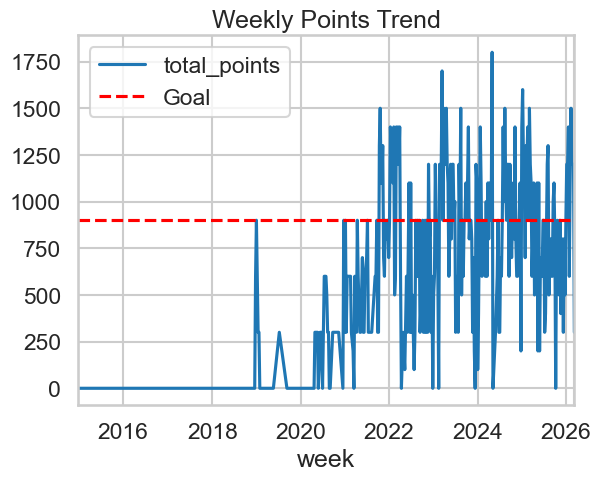

In [42]:
import matplotlib.pyplot as plt
weekly_points.set_index('week')['total_points'].plot(title='Weekly Points Trend')
plt.axhline(900, color='r', linestyle='--', label='Goal')
plt.legend(); plt.show()

Top 10 words in high-effort workouts:
[('cycling', 192), ('hard', 192), ('interval', 192), ('run', 192), ('gym', 190), ('running', 189)]


FileNotFoundError: [Errno 2] No such file or directory: 'figures/high_effort_wordcloud.png'

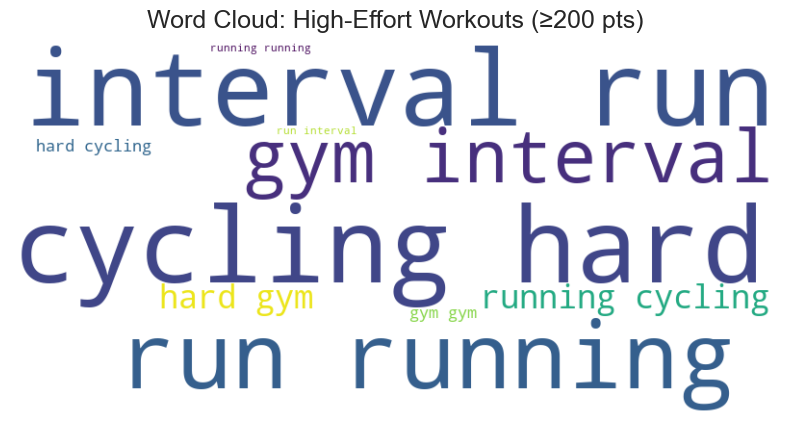

In [44]:
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

# Assume you extract 'activity_name' or 'description' from .fit "session" messages
# If not yet extracted, add in your _extract_fit_data function:
# session = next(fitfile.get_messages("session"), None)
# if session:
#     data['activity_name'] = session.get_value("sport") or session.get_value("sub_sport") or "Unknown"
#     data['description'] = session.get_value("notes") or ""   # if notes field exists

# For now, if you have the column (or rename to match):
# df_fit['activity_text'] = df_fit['activity_name'].fillna('') + ' ' + df_fit['description'].fillna('')

# Placeholder: replace with your actual text column
df_fit['activity_text'] = df_fit.get('activity_name', pd.Series(['Running', 'Cycling Hard', 'Gym', 'Interval Run'] * len(df_fit)))  # demo

# Filter high-effort workouts
high_effort = df_fit[df_fit['estimated_points'] >= 200].copy()
high_effort = high_effort[high_effort['activity_text'].str.strip() != '']

if not high_effort.empty:
    text = ' '.join(high_effort['activity_text'].str.lower())
    words = [w for w in text.split() if w.isalpha() and w not in stop_words and len(w) > 2]
    
    # Most common words
    word_counts = Counter(words)
    print("Top 10 words in high-effort workouts:")
    print(word_counts.most_common(10))
    
    # Word cloud
    wc = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(' '.join(words))
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title("Word Cloud: High-Effort Workouts (≥200 pts)")
    plt.savefig('figures/high_effort_wordcloud.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No high-effort workouts with text descriptions found.")

FileNotFoundError: [Errno 2] No such file or directory: 'figures/weekly_points_trend_rolling.png'

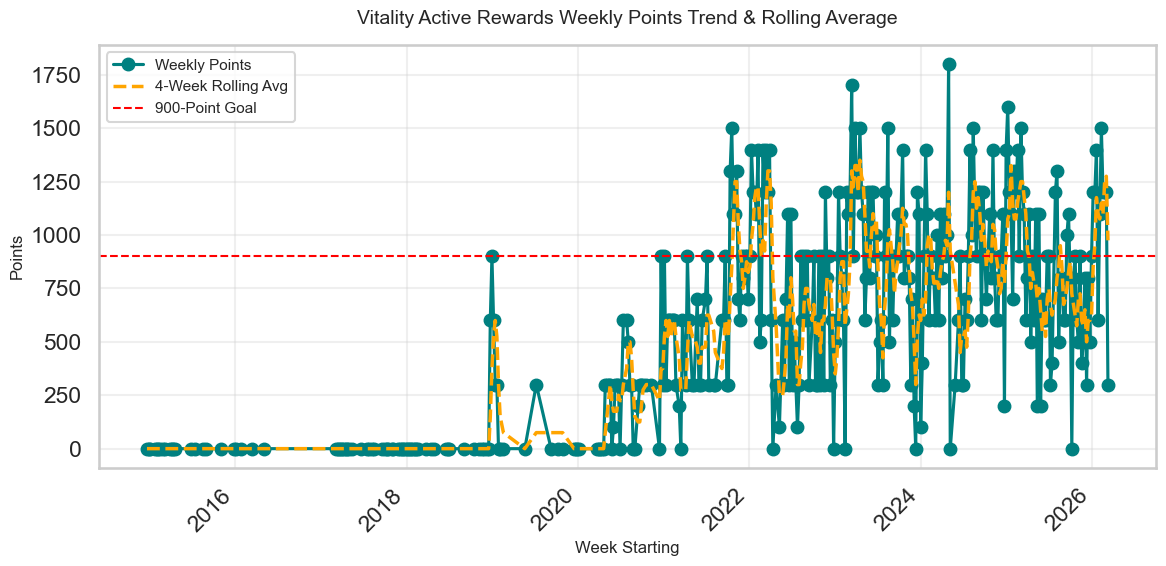

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

weekly_points = weekly_points.sort_values('week').copy()
weekly_points.set_index('week', inplace=True)

fig, ax = plt.subplots(figsize=(12, 6))

# Actual weekly points
ax.plot(weekly_points.index.to_timestamp(), weekly_points['total_points'], 
        marker='o', linestyle='-', color='teal', label='Weekly Points')

# 4-week rolling average
rolling_avg = weekly_points['total_points'].rolling(window=4, min_periods=1).mean()
ax.plot(weekly_points.index.to_timestamp(), rolling_avg, 
        color='orange', linewidth=2.5, linestyle='--', label='4-Week Rolling Avg')

ax.axhline(900, color='red', linestyle='--', linewidth=1.5, label='900-Point Goal')

ax.set_title('Vitality Active Rewards Weekly Points Trend & Rolling Average', fontsize=14, pad=15)
ax.set_xlabel('Week Starting', fontsize=12)
ax.set_ylabel('Points', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Rotate x-ticks for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('figures/weekly_points_trend_rolling.png', dpi=300, bbox_inches='tight')
plt.show()